# Downloading JWST and Euclid data

In [1]:
import requests
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
# Replace this with your Dropbox shared link and modify to dl=1 at the end
dropbox_url = "https://www.dropbox.com/scl/fi/ibbxaq0fj9gkodsu0idow/EUC_MER_BGSUB-MOSAIC-NIR-J_TILE[…]Z_00.00.fits?rlkey=i1pnapefx2uj20v7y33lkl3e3&st=egn0es4i&dl=1"
# Stream the FITS file
response = requests.get(dropbox_url)
response.raise_for_status()  # Ensure successful request
# Read FITS file from memory
fits_file = BytesIO(response.content)
hdul = fits.open(fits_file)
# Display FITS file info
hdul.info()
# Access image data
image_data = hdul[0].data
hdul.close()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      48   (10200, 10200)   float32   


In [3]:
folder_url = "https://caltech.box.com/s/3ykklf78uj89nm0wrc3tpwkkakpsmjju?dl=1"
response = requests.get(folder_url)
response.raise_for_status()

## Using Dropbox API

In [1]:
import requests
import os
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import numpy as np
import pandas as pd
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
import warnings
from astropy.wcs import FITSFixedWarning
from scipy import ndimage

In [2]:
warnings.simplefilter('ignore', FITSFixedWarning)

In [3]:
# Authenticate dropbox
# Go to https://www.dropbox.com/developers/apps?_tk=pilot_lp&_ad=topbar4&_camp=myapps and generate new token,
#    then copy and paste the token to a file of your choice, or directly to this cell
with open("/Users/emily_ramey/secrets/dropbox_token") as token_file:
    token = token_file.read()
    dbx = dropbox.Dropbox(token.strip())

In [4]:
# Links to shared folders
parent_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AK5SQfnqsfDYbqvUW1WVESI?rlkey=enfshikpl0r0wd8o2nz66i0km&e=1&st=brev767o&dl=0'
jwst_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/ANfH2VisN0vIphVxNIpO_ag/JWST?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=w3u4yz80&dl=0'
nisp_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AEiIbqfbMKqh6FRA2YouLHQ/NISP-J?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=hx3ru322&dl=0'

# Catalog files
farmer_cat_path = '../catalog/COSMOS2020_FARMER_R1_v2.2_p3.fits'
classic_cat_path = '../catalog/COSMOS2020_CLASSIC_R1_v2.2_p3.fits'

# Data files
np_jwst_file = "../data/jwst_data.npy"
np_nisp_file = "../data/nisp_data.npy"

In [5]:
def get_shared_folder_metadata(url):
    """Get metadata of the shared folder."""
    shared_link = dropbox.files.SharedLink(url=url)
    try:
        folder_metadata = dbx.files_list_folder(path="", shared_link=shared_link)
        return folder_metadata.entries
    except dropbox.exceptions.ApiError as e:
        print(f"Error accessing shared folder: {e}")
        return []

def get_fits_file(url, file_name):
    meta, res = dbx.sharing_get_shared_link_file(url, path='/'+file_name)

    fits_file = BytesIO(res.content)
    hdul = fits.open(fits_file)

    # Access image data
    image_data = hdul[0].data
    image_header = hdul[0].header
    hdul.close()
    return image_header, image_data

def cut_catalog(cat_file=classic_cat_path, cuts=None):
    # Open cat file
    with fits.open(classic_cat_path) as hdul:
        cat_data = hdul[1].data  # Adjust the HDU index if your data is not in the first extension
    
    # Do cuts on catalog data
    if cuts is None:
        cuts = (cat_data.lp_type==0) & \
                (cat_data.ACS_F814W_MAG < 25) & \
                (cat_data.ez_z_phot > 0.01) & (cat_data.ez_z_phot < 3.0) & \
                (cat_data.FLUX_RADIUS < 24) # TODO: make this a function with J&H bands?
    
    cat_clipped = cat_data[cuts]
    
    my_cat = pd.DataFrame({'id_classic': cat_clipped['ID'].astype(int),
                           'ra': cat_clipped['ALPHA_J2000'].astype(float),
                           'dec': cat_clipped['DELTA_J2000'].astype(float),
                           'jwst_image': "",
                           'nisp_image': "",
                          })
    
    return my_cat

def match_catalog(url, file_name, gal_coords):
    # Open FITS file
    image_header, image_data = get_fits_file(url, file_name)
    wcs = WCS(image_header)
    
    return np.where(gal_coords.contained_by(wcs))[0]

def rotate_jwst(clip, angle=-20, size=66, pad=20):
    if not clip.data.shape[0]>=size+pad:
        raise ValueError("Clip size is too small to rotate, make clips larger and then crop")
    # There are different types of interpolation possible for this one, talk about it with Shooby
    new_image = ndimage.rotate(clip.data, angle, reshape=False, cval=-20)
    new_clip = Cutout2D(new_image, clip.center_cutout, size)
    return new_clip # no WCS info after this

In [6]:
jwst_files = get_shared_folder_metadata(jwst_url)
nisp_files = get_shared_folder_metadata(nisp_url)

In [7]:
# # Make the clipped catalog:
# my_cat = cut_catalog()
# gal_coords = SkyCoord(my_cat.ra, my_cat.dec, unit='deg')

# # Sort through and match JWST images
# for file in jwst_files:
#     found_idxs = match_catalog(jwst_url, file.name, gal_coords)
#     my_cat.loc[found_idxs, 'jwst_image'] = str(file.name)

# # Sort through and match Euclid images
# for file in nisp_files:
#     found_idxs = match_catalog(nisp_url, file.name, gal_coords)
#     my_cat.loc[found_idxs, 'nisp_image'] = str(file.name)

# my_cat = my_cat[my_cat.nisp_image!='']
# my_cat = my_cat[my_cat.jwst_image!='']
# my_cat.to_csv("../catalog/match_catalog.dat", index=False)

In [8]:
my_cat = pd.read_csv('../catalog/match_catalog.csv')

In [9]:
# if os.path.exists(np_jwst_file):
#     jwst_cutouts = np.load(np_jwst_file)
#     nisp_cutouts = np.load(np_nisp_file)

In [10]:
image_pairs = my_cat.groupby(['jwst_image', 'nisp_image'])
N = len(my_cat) # Change to len(my_cat) for full run
size_jwst = 66
size_nisp = 40
pad = 20

# jwst_cutouts = np.zeros((N, size_jwst, size_jwst))
# nisp_cutouts = np.zeros((N, size_nisp, size_nisp))

# counter = 0
clips = []
for pair, cat in image_pairs:
    jwst_file, nisp_file = pair
    
    # Open JWST and Euclid images
    jwst_header, jwst_data = get_fits_file(jwst_url, jwst_file)
    nisp_header, nisp_data = get_fits_file(nisp_url, nisp_file)
    wcs_jwst, wcs_nisp = WCS(jwst_header), WCS(nisp_header)
    
    # Get the coordinates of matched galaxies
    gal_coords = SkyCoord(cat.ra, cat.dec, unit='deg')
    
    for i in range(len(cat)):
        gal = cat.iloc[i]
        # Get JWST clip (larger than final size)
        clip_jwst = Cutout2D(jwst_data, gal_coords[i], size=size_jwst+pad, wcs=wcs_jwst, mode='trim')
        if sum(clip_jwst.data.shape)!=(size_jwst+pad)*2: continue
        
        # Get NISP clip
        clip_nisp = Cutout2D(nisp_data, gal_coords[i], size=size_nisp, wcs=wcs_nisp, mode='trim')
        if sum(clip_nisp.data.shape)!=(size_nisp)*2: continue
        
        # Rotate JWST image 20 degrees counter-clockwise and crop
        # This loses the WCS
        clip_jwst = rotate_jwst(clip_jwst, size=size_jwst)
        
        clips.append((gal_coords[i], clip_jwst, clip_nisp))
        
#         counter+=1
#         if counter>=N: break
    
#     if counter>=N: break

# Arrange cutouts in numpy arrays
jwst_cutouts = np.array([clip[1].data for clip in clips])
nisp_cutouts = np.array([clip[2].data for clip in clips])

In [11]:
# nisp_ps = 0.09999975642693848
# jwst_ps = 0.05999903327225375
# # center, center_1 = clip_nisp.wcs.pixel_to_world(40, 40), clip_nisp.wcs.pixel_to_world(41, 40)
# # center.separation(center_1).arcsecond # NISP is 0.1"/pixel, JWST is 0.06"/pixel
# nisp_ps / jwst_ps * 20 # = JWST image size = 33.33378922062828 pixels (rounding up to 34)
# # New NISP size = 40, so JWST size is 66 (rounded down)

In [12]:
# corners = np.array([[0,0],[0,size_nisp],[size_nisp,size_nisp],[size_nisp,0],[0,0]])
# # [[0, 0, size_nisp, size_nisp],[0, size_nisp, 0, size_nisp]]
# corner_coords = clip_nisp.wcs.pixel_to_world(corners[:,0], corners[:,1])
# jwst_corners = clip_jwst.wcs.world_to_pixel(corner_coords)
# plt.imshow(clip_jwst.data)
# plt.plot(jwst_corners[0], jwst_corners[1], 'r-')

# pt1 = np.array(jwst_corners)[:,1]
# pt2 = np.array(jwst_corners)[:,2]
# pt3 = np.array([x1+34,y1])

# plt.plot([pt1[0],pt3[0]],[pt1[1],pt3[1]], 'r--')
# v1 = pt2-pt1
# v2 = pt3-pt1
# mag_v1 = np.sqrt(np.dot(v1,v1))
# mag_v2 = np.sqrt(np.dot(v2,v2))
# mag_v1, mag_v2

# np.arccos(np.dot(v1,v2)/(mag_v1*mag_v2))*180/np.pi # Shooby was right! Almost exactly 20 degrees

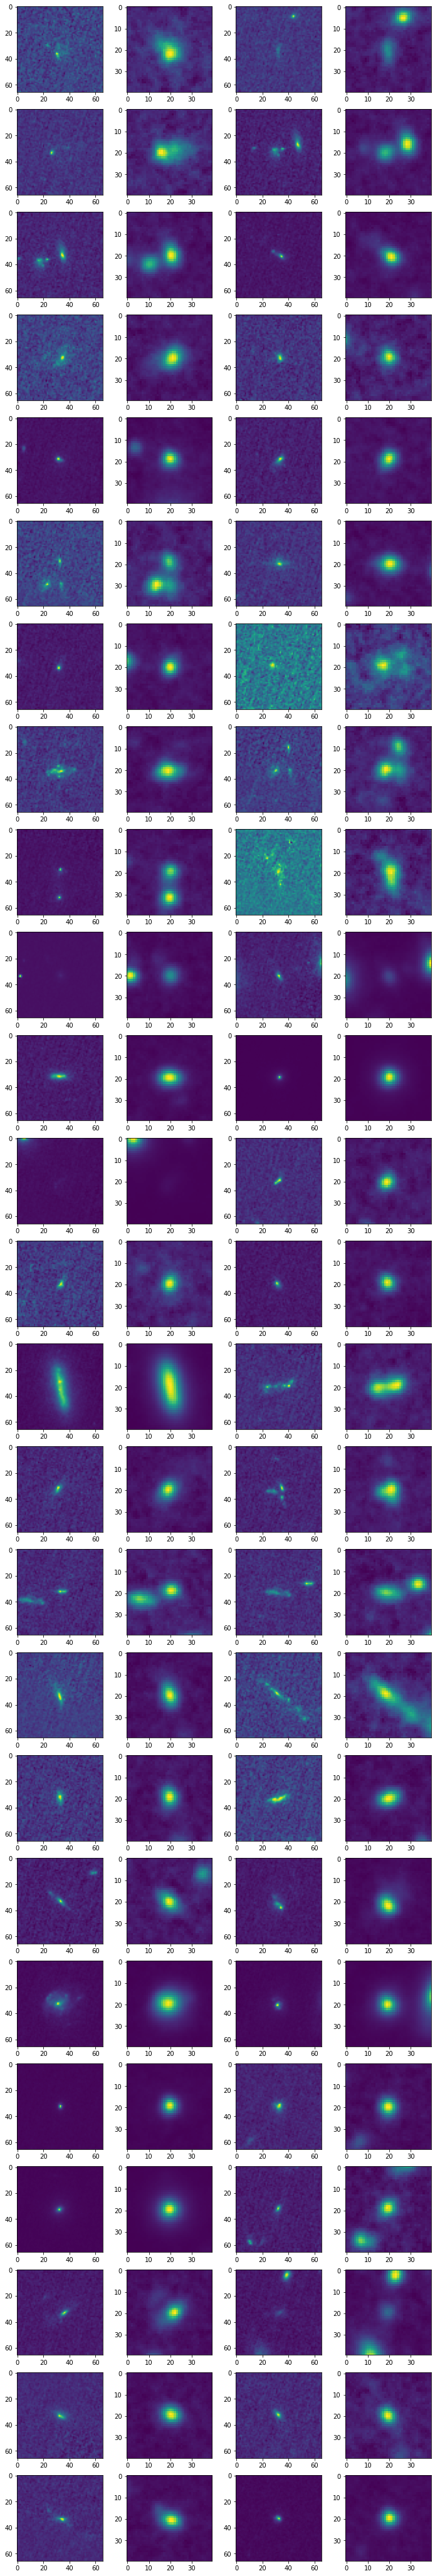

In [13]:
# Plotting newly rotated images
fig, axes = plt.subplots(25, 4, figsize=(12,75))
for i,val in enumerate(clips[:50]):
    clip_jwst, clip_nisp = val[1:]
    axes.flatten()[i*2].imshow(clip_jwst.data)
    axes.flatten()[i*2+1].imshow(clip_nisp.data)

In [14]:
jwst_cutouts.shape, f'{jwst_cutouts.nbytes/1e9:.2f} Gb'

((38695, 66, 66), '0.67 Gb')

In [15]:
# # Can we maybe just save it as a binary file if we don't need the metadata? Yes
# # np_bytes = BytesIO()
# # np.save(np_bytes, jwst_cutouts, allow_pickle=False)

np_jwst_file = '../data/jwst_data_66px.npy'
np_nisp_file = '../data/nisp_data_40px.npy'

np.save(np_jwst_file, jwst_cutouts, allow_pickle=False)
np.save(np_nisp_file, nisp_cutouts, allow_pickle=False)

In [16]:
import os
f'{os.path.getsize(np_jwst_file)/1e9:.2f} Gb' # Same size as the initial array

'0.67 Gb'

In [17]:
# Some older reference info:
# N1, N2 = image_data.shape # Data is in Y, X format, so Y axis is 12455 and X axis is 9600
# # Corners for input into pixel_to_world are in X, Y format! (0,0), (9600,0), (0,12455), and (9600,12455)
# corners = np.array([[0, 0], [N1, 0], [0, N2], [N1, N2]])
# corners_sky = wcs.pixel_to_world(corners[:,1], corners[:,0])
# corners_sky

In [18]:
# Euclid NISP = 0.3 as/px # This is not right, it is actually 0.1"/pixel
# JWST NIRCAM = 0.06 as/px
# Can do 100/20 px (exact ratio) or 128/24 px (less exact but might be better round numbers for GAN)

# Starting on the SR GAN

In [15]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import wandb
import random

ModuleNotFoundError: No module named 'wandb'

In [2]:
jwst_file = "../data/jwst_data_66px.npy"
nisp_file = "../data/nisp_data_40px.npy"

In [3]:
tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

def transform_data(img_data, tiny=1e-8):
    # Flattens higher values
    img_data = np.arcsinh(img_data)
    
    # Normalize to [0,1]
    img_data = (img_data - img_data.min()) / (img_data.max() - img_data.min() + tiny)
    # Can this normalization be reversed without knowing what the max / min values were?
    
    # Transform
    return tfms(img_data.astype(np.float32))  # Convert properly

In [4]:
class SuperResolutionDataset(Dataset):
    def __init__(self, lr_path, hr_path=None, transform=None, inference_mode=False, 
                 split='train', sample_fraction=1.0, seed=42):
        """
        Dataset that loads LR images and optionally HR images.

        :param lr_hdf5_path: Path to Low-Resolution numpy file
        :param hr_hdf5_path: Path to High-Resolution numpy file (optional)
        :param transform: Optional torchvision transforms
        :param inference_mode: If True, returns only LR images (for super-res inference)
        """
        np.random.seed(seed)
        self.lr_path = lr_path
        self.hr_path = hr_path  # Can be None
        self.transform = transform
        self.split = split
        self.inference_mode = inference_mode  # If True, load only LR

        # Load keys from LR file
        self.lr_data = np.load(self.lr_path, mmap_mode='r')
        # Using self.keys as indices
        self.keys = np.arange(self.lr_data.shape[0])
        
        # TODO: Ask Shooby what percentage she wants in train/test split
        if self.split=='train': # Take 80%
            N = int(len(self.keys) * 0.8)
            self.keys = np.random.choice(self.keys, N, replace=False)
        else: # Take 20%
            N = int(len(self.keys)*0.2)
            self.keys = np.random.choice(self.keys, N, replace=False)
        
        # Subsample the dataset
        if sample_fraction < 1.0:
            num_samples = int(len(self.keys) * sample_fraction)
            self.keys = np.random.choice(self.keys, num_samples, replace=False)
        
        self.lr_data = self.lr_data[self.keys]

        # Check if HR exists
        self.has_hr = hr_path is not None
        if self.has_hr:
            self.hr_data = np.load(self.hr_path, mmap_mode='r')
            self.hr_data = self.hr_data[self.keys]
    
    def __len__(self):
        return len(self.lr_data)

    def __getitem__(self, idx):

        # Read one part of numpy array
        lr_image = transform_data(self.lr_data[idx])

        # Convert to tensor
        lr_image = torch.tensor(lr_image, dtype=torch.float32)

        # If in inference mode OR no HR data, return only LR image
        if self.inference_mode or not self.has_hr:
            return lr_image

        # Load HR image only if available
        hr_image = transform_data(self.hr_data[idx])
        hr_image = torch.tensor(hr_image, dtype=torch.float32)
        return lr_image, hr_image  # Training case (LR, HR)

In [5]:
# Load Training Dataset (for checking shape)
train_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Get a batch for training
lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)

# Load Test Dataset (for evaluation)
test_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Get a batch for inference (only LR images)
lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)

/Users/emily_ramey/opt/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/Users/emily_ramey/opt/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


Training Mode:
LR Batch Shape: torch.Size([16, 1, 40, 40])
HR Batch Shape: torch.Size([16, 1, 66, 66])
Inference Mode:
LR Batch Shape: torch.Size([16, 1, 40, 40])
HR Batch Shape: torch.Size([16, 1, 66, 66])


In [6]:
# UNet with Cross-Attention
class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim * 2, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 3, padding=1, stride=2),
            nn.ReLU(),
        )

        # Ensure condition matches x channels
        self.condition_proj = nn.Conv2d(1, hidden_dim * 4, kernel_size=3, padding=1)

        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim * 4, num_heads=4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x, condition):
        x = x.to(next(self.parameters()).device) 
        condition = condition.to(next(self.parameters()).device)

        x = self.encoder(x)
        condition = self.condition_proj(condition)

        batch_size, channels, height, width = x.shape

        # Flatten height & width dimensions before attention
        x = x.flatten(2).permute(2, 0, 1)
        condition = condition.flatten(2).permute(2, 0, 1)

        x, _ = self.cross_attention(x, condition, condition)

        # Reshape back to image format
        x = x.permute(1, 2, 0).view(batch_size, channels, height, width)
        x = self.decoder(x)
        return x

# Diffusion Model
class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=100):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps

    def forward(self, x, t, condition):
        x = x.to(next(self.parameters()).device)  
        t = t.to(next(self.parameters()).device)
        condition = condition.to(next(self.parameters()).device)
        return self.unet(x, condition)

class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.upsample = nn.Upsample(size=(66, 66), mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = x.to(next(self.parameters()).device)  
        x = self.upsample(x)
        return self.conv(x)

# Full Model
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        x = x.to(next(self.parameters()).device)  
        t = t.to(next(self.parameters()).device)
        
        upscaled = self.upsampler(x)

        # Add progressive noise instead of replacing
        noise = torch.randn_like(upscaled, device=upscaled.device)  
        alpha_t = torch.sqrt(1 - (t / self.diffusion.timesteps).float().view(-1, 1, 1, 1))
        noisy_image = alpha_t * upscaled + (1 - alpha_t) * noise

        return self.diffusion(noisy_image, t, upscaled)

# Instantiate models and move them to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

# Example input on GPU
x = torch.randn(1, 1, 40, 40, device=device) 
t = torch.tensor([500], device=device) 

# Run the model
output = model(x, t)

print("Output shape:", output.shape)

Output shape: torch.Size([1, 1, 66, 66])


/Users/emily_ramey/opt/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/Users/emily_ramey/opt/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


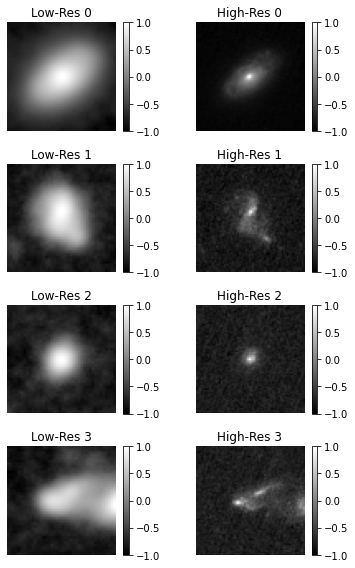

In [9]:
# Load Training Dataset (set split="train" explicitly)
train_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Fetch a batch from the training dataset
lr_batch, hr_batch = next(iter(train_loader))

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.squeeze().cpu().numpy()  
hr_batch_np = hr_batch.squeeze().cpu().numpy()  

# Plot first 4 samples
fig, axes = plt.subplots(4, 2, figsize=(6, 8))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)  # Add colorbar

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()
plt.show()

In [14]:
# Use Mean Squared Error (MSE) Loss for Super-Resolution
criterion = nn.MSELoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
num_epochs = 3

# Train-Test Dataloaders
train_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="train", sample_fraction=0.1),
    batch_size=128, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="test"),
    batch_size=128, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True
)

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    print(f"Starting Epoch {epoch+1}...") 

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):

        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)
        
        output = model(lr_batch, t)# Forward pass
        loss = criterion(output, hr_batch)# Compute loss
        epoch_loss += loss.item()
        
        optimizer.zero_grad()# Backpropagation
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")

# Save trained model
torch.save(model.state_dict(), "super_resolution_model.pth")
print("Model saved successfully!")

Starting Epoch 1...


/Users/emily_ramey/opt/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/Users/emily_ramey/opt/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/Users/emily_ramey/opt/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/Users/emily_ramey/opt/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:54: 

Epoch [1/3], Loss: 0.516127, Time: 1221.46s
Starting Epoch 2...
Epoch [2/3], Loss: 0.116020, Time: 991.74s
Starting Epoch 3...
Epoch [3/3], Loss: 0.066200, Time: 1047.61s
Model saved successfully!
